# Model EDA
**Mục tiêu**: Phân tích dữ liệu đã xử lý dùng để train model, tìm insight phục vụ feature selection & model building.

Dữ liệu load từ `data/processed/data_eda.csv` (đã fill missing, chưa scale, có bucket hóa).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded ✓")


Libraries loaded ✓


In [2]:
df = pd.read_csv("../../data/processed/data_eda.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head()


Shape: (132955, 31)


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,...,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5,discount_rate_norm,log_sales,price_bucket,page_bucket,discount_bucket
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",83930,109000,23,4.8,7257,75282,Tống Mặc,Skybooks,...,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN,0.23,11.229010,50-100k,100-300,10-30%
1,52789367,Sách Nhà Giả Kim (Tái Bản),78000,95000,18,5.0,6076,39825,Paulo Coelho,Nhã Nam,...,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai,0.18,10.592275,50-100k,100-300,10-30%
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",137830,179000,23,4.8,5492,27187,Cao Minh,Vibooks,...,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai,0.23,10.210531,100-200k,300-500,10-30%
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,60830,79000,23,4.7,5338,13,Ở Đây Zui Nè,Skybooks,...,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam,0.23,2.639057,50-100k,100-300,10-30%
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,173462,248000,30,4.8,5294,31431,David A. Phillips,First News - Trí Việt,...,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN,0.30,10.355582,100-200k,300-500,10-30%


In [3]:
df.describe()


,id,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,number_of_page,stock,discount_rate_norm,log_sales
count,1.329550e+05,1.329550e+05,1.329550e+05,132955.000000,132955.000000,132955.000000,132955.000000,1.329550e+05,132579.0,132955.000000,132955.000000
mean,2.140448e+08,1.803609e+05,1.932208e+05,6.726697,1.143218,6.110774,54.105720,1.441356e+04,1000.0,0.067267,1.231466
std,8.904153e+07,2.125998e+05,2.235136e+05,10.549624,2.060529,79.503230,678.679874,2.313614e+06,0.0,0.105496,1.700202
min,3.136070e+05,0.000000e+00,4.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1000.0,0.000000,0.000000
25%,1.819931e+08,8.000000e+04,8.900000e+04,0.000000,0.000000,0.000000,0.000000,2.630000e+02,1000.0,0.000000,0.000000
50%,2.706603e+08,1.348000e+05,1.480000e+05,0.000000,0.000000,0.000000,1.000000,2.630000e+02,1000.0,0.000000,0.693147
75%,2.768091e+08,2.130000e+05,2.290000e+05,10.000000,0.000000,0.000000,6.000000,2.630000e+02,1000.0,0.100000,1.945910
max,2.793159e+08,9.990000e+06,1.003000e+07,100.000000,5.000000,7257.000000,75282.000000,4.362883e+08,1000.0,1.000000,11.229010


---
## 1. Phân phối Target: `all_time_quantity_sold`


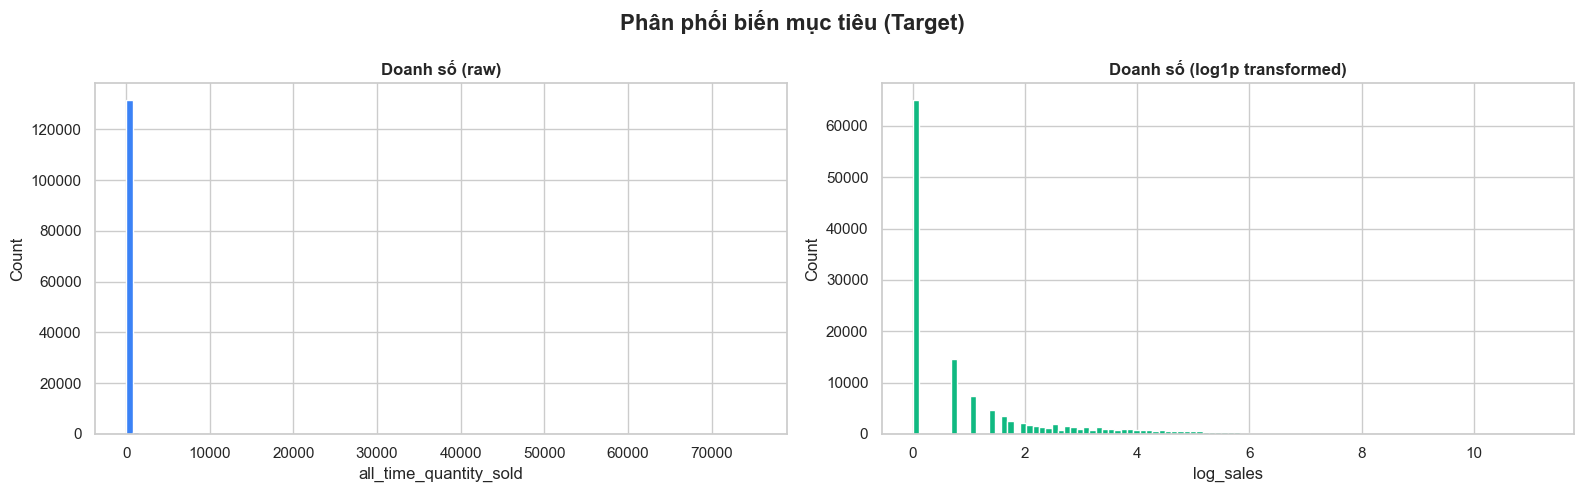

Raw  - mean: 54.1, median: 1.0, skew: 47.87
Log  - mean: 1.23, median: 0.69, skew: 1.56

=> Phân phối lệch phải cực mạnh, log transform giúp giảm skewness đáng kể.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw
axes[0].hist(df['all_time_quantity_sold'].dropna(), bins=100, color='#3b82f6', edgecolor='white')
axes[0].set_title('Doanh số (raw)', fontweight='bold')
axes[0].set_xlabel('all_time_quantity_sold')
axes[0].set_ylabel('Count')

# Log
axes[1].hist(df['log_sales'].dropna(), bins=100, color='#10b981', edgecolor='white')
axes[1].set_title('Doanh số (log1p transformed)', fontweight='bold')
axes[1].set_xlabel('log_sales')
axes[1].set_ylabel('Count')

plt.suptitle('Phân phối biến mục tiêu (Target)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Raw  - mean: {df['all_time_quantity_sold'].mean():.1f}, median: {df['all_time_quantity_sold'].median():.1f}, skew: {df['all_time_quantity_sold'].skew():.2f}")
print(f"Log  - mean: {df['log_sales'].mean():.2f}, median: {df['log_sales'].median():.2f}, skew: {df['log_sales'].skew():.2f}")
print(f"\n=> Phân phối lệch phải cực mạnh, log transform giúp giảm skewness đáng kể.")


---
## 2. Ma trận tương quan (Correlation Matrix)


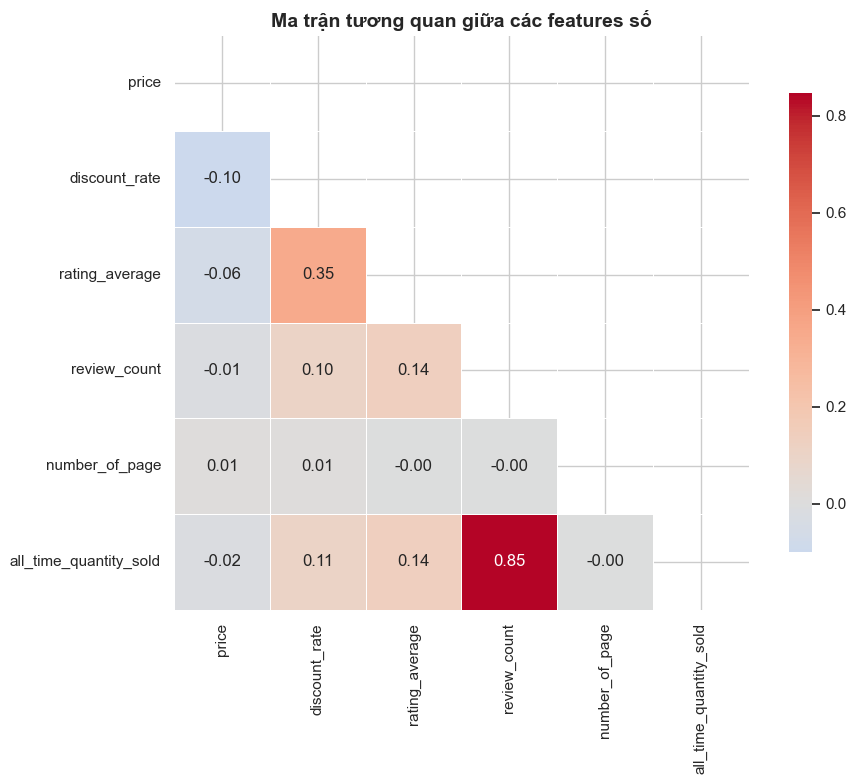

Tương quan với all_time_quantity_sold:
  review_count                  : +0.848 (MẠNH)
  rating_average                : +0.138 (TRUNG BÌNH)
  discount_rate                 : +0.108 (TRUNG BÌNH)
  number_of_page                : -0.000 (YẾU)
  price                         : -0.017 (YẾU)


In [5]:
corr_cols = ['price', 'discount_rate', 'rating_average', 'review_count', 'number_of_page', 'all_time_quantity_sold']
corr_matrix = df[corr_cols].dropna().corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan giữa các features số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tương quan với all_time_quantity_sold:")
target_corr = corr_matrix['all_time_quantity_sold'].drop('all_time_quantity_sold').sort_values(ascending=False)
for feat, val in target_corr.items():
    strength = "MẠNH" if abs(val) > 0.3 else "TRUNG BÌNH" if abs(val) > 0.1 else "YẾU"
    print(f"  {feat:30s}: {val:+.3f} ({strength})")


---
## 3. Rating vs Doanh số


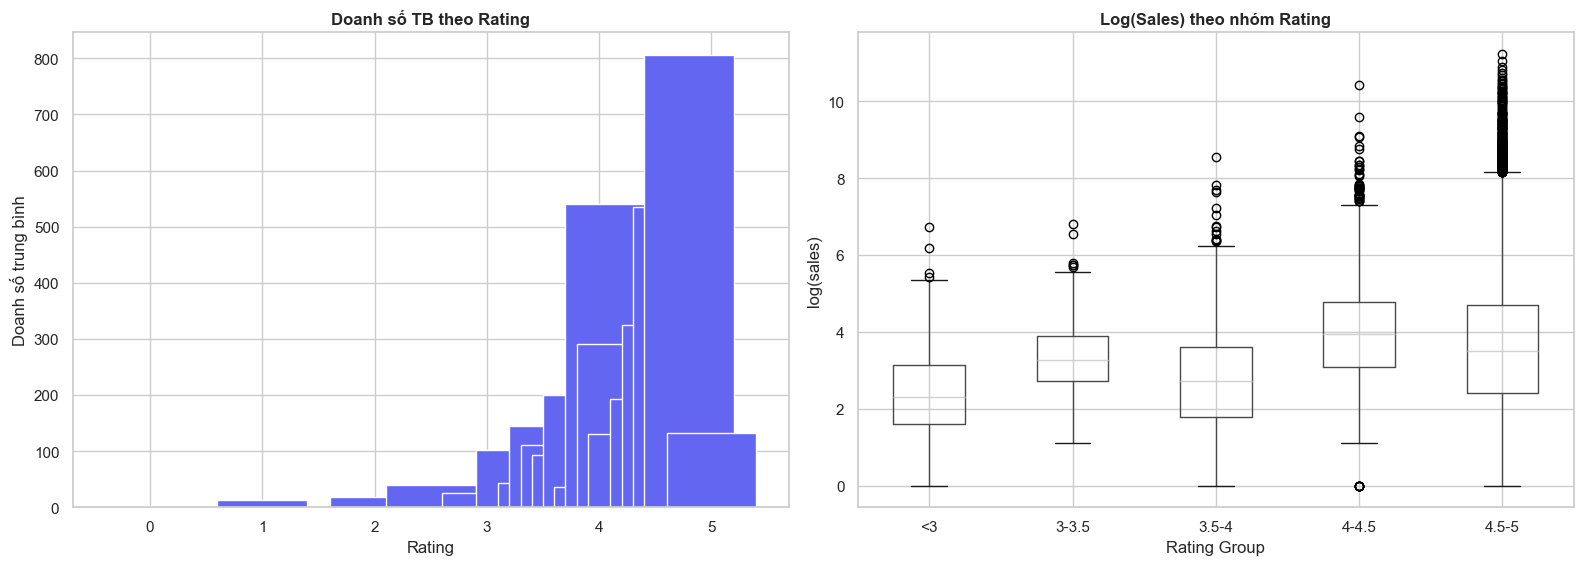

=> Rating 4.5-5.0 cho doanh số trung bình cao nhất
=> Tuy nhiên sách không có rating (=0) cũng chiếm rất nhiều


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar: Mean sales by rating
rating_sales = df.groupby(df['rating_average'].round(1))['all_time_quantity_sold'].agg(['mean', 'count']).reset_index()
rating_sales = rating_sales[rating_sales['count'] >= 10]
axes[0].bar(rating_sales['rating_average'], rating_sales['mean'], color='#6366f1', edgecolor='white')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Doanh số trung bình')
axes[0].set_title('Doanh số TB theo Rating', fontweight='bold')

# Box: Sales distribution by rating group
df['rating_group'] = pd.cut(df['rating_average'], bins=[0, 3, 3.5, 4, 4.5, 5.1], labels=['<3', '3-3.5', '3.5-4', '4-4.5', '4.5-5'])
df.boxplot(column='log_sales', by='rating_group', ax=axes[1])
axes[1].set_title('Log(Sales) theo nhóm Rating', fontweight='bold')
axes[1].set_xlabel('Rating Group')
axes[1].set_ylabel('log(sales)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("=> Rating 4.5-5.0 cho doanh số trung bình cao nhất")
print("=> Tuy nhiên sách không có rating (=0) cũng chiếm rất nhiều")


---
## 4. Discount vs Doanh số


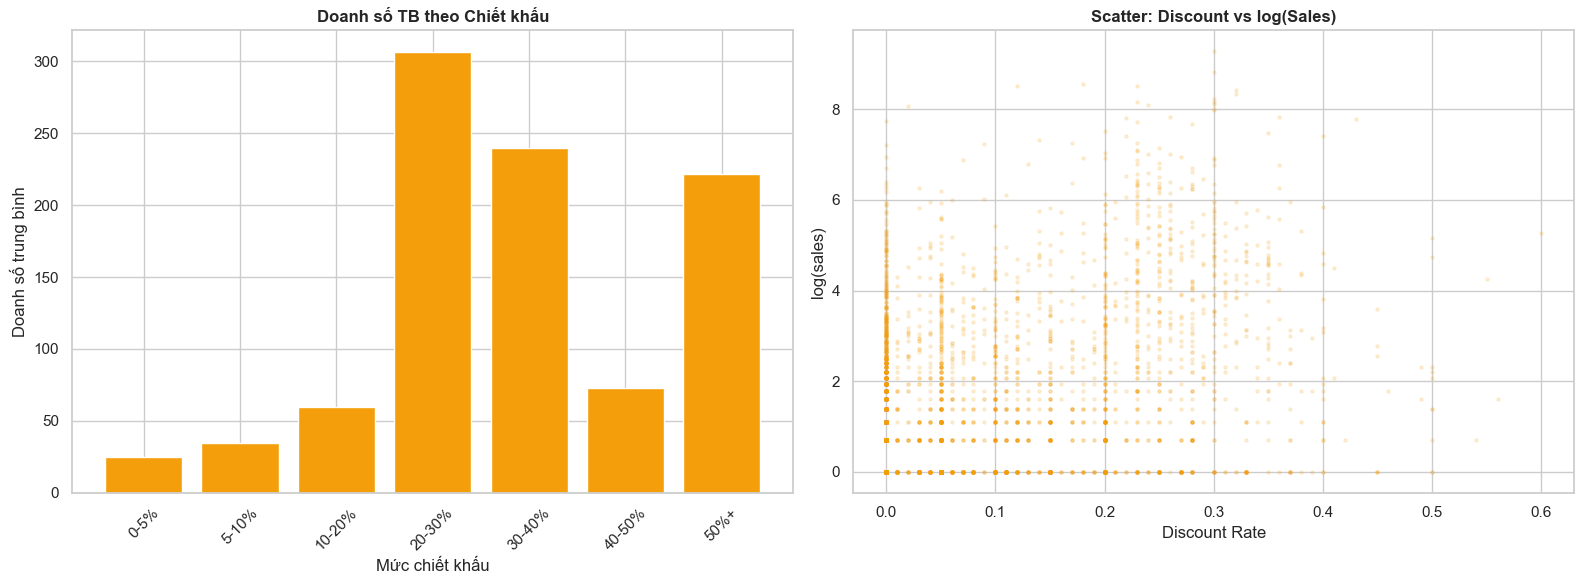

=> Chiết khấu 20-30% cho doanh số trung bình cao nhất


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ensure discount_rate_norm exists
if 'discount_rate_norm' not in df.columns:
    if df['discount_rate'].max() > 1:
        df['discount_rate_norm'] = df['discount_rate'] / 100.0
    else:
        df['discount_rate_norm'] = df['discount_rate']

# Bar: mean sales by discount bucket
discount_bins = pd.cut(df['discount_rate_norm'], bins=[0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                       labels=['0-5%', '5-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'])
disc_sales = df.groupby(discount_bins, observed=True)['all_time_quantity_sold'].agg(['mean', 'count']).reset_index()
axes[0].bar(range(len(disc_sales)), disc_sales['mean'], color='#f59e0b', edgecolor='white')
axes[0].set_xticks(range(len(disc_sales)))
axes[0].set_xticklabels(disc_sales['discount_rate_norm'], rotation=45)
axes[0].set_xlabel('Mức chiết khấu')
axes[0].set_ylabel('Doanh số trung bình')
axes[0].set_title('Doanh số TB theo Chiết khấu', fontweight='bold')

# Scatter
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['discount_rate_norm'], sample['log_sales'], alpha=0.15, s=5, c='#f59e0b')
axes[1].set_xlabel('Discount Rate')
axes[1].set_ylabel('log(sales)')
axes[1].set_title('Scatter: Discount vs log(Sales)', fontweight='bold')

plt.tight_layout()
plt.show()

print("=> Chiết khấu 20-30% cho doanh số trung bình cao nhất")


---
## 5. Review Count vs Doanh số


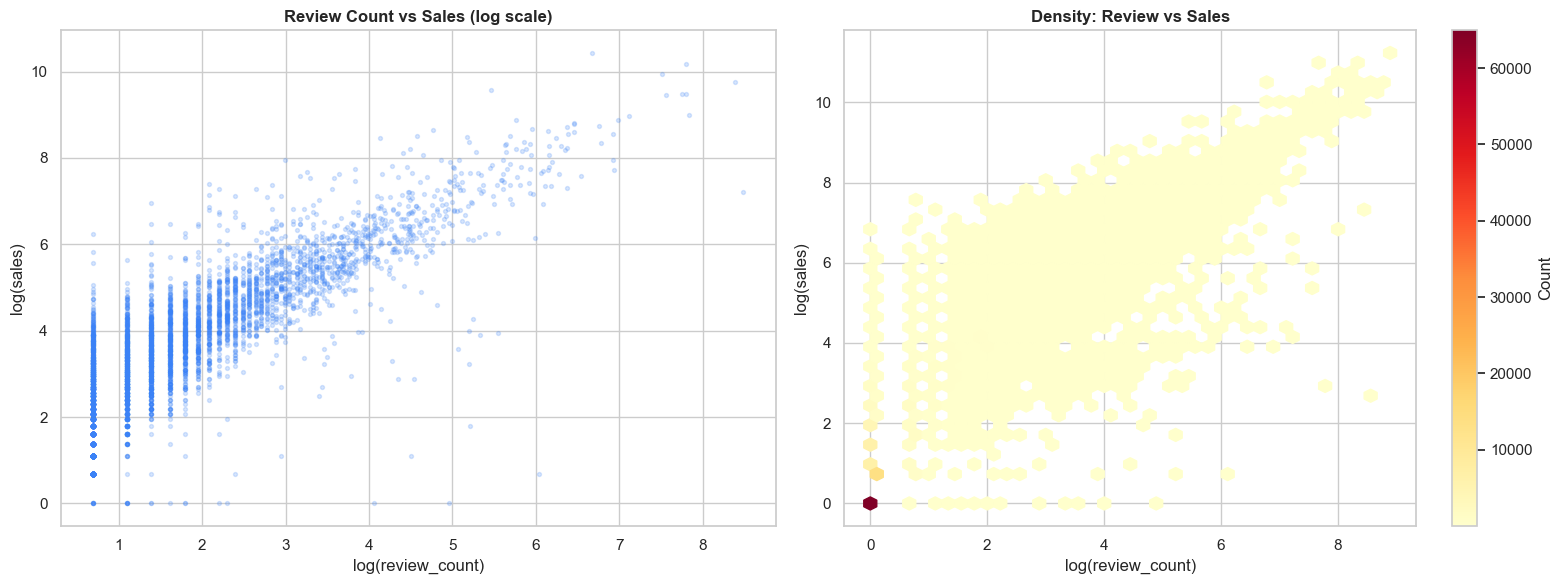

Pearson correlation (review_count, sales): 0.8479
=> review_count có tương quan MẠNH nhất với doanh số — hiệu ứng đám đông!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
sample = df[df['review_count'] > 0].sample(min(5000, len(df[df['review_count']>0])), random_state=42)
axes[0].scatter(np.log1p(sample['review_count']), np.log1p(sample['all_time_quantity_sold']),
               alpha=0.2, s=8, c='#3b82f6')
axes[0].set_xlabel('log(review_count)')
axes[0].set_ylabel('log(sales)')
axes[0].set_title('Review Count vs Sales (log scale)', fontweight='bold')

# Heatmap 2D
axes[1].hexbin(np.log1p(df['review_count']), df['log_sales'], gridsize=40, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('log(review_count)')
axes[1].set_ylabel('log(sales)')
axes[1].set_title('Density: Review vs Sales', fontweight='bold')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

corr = df[['review_count', 'all_time_quantity_sold']].dropna().corr().iloc[0, 1]
print(f"Pearson correlation (review_count, sales): {corr:.4f}")
print("=> review_count có tương quan MẠNH nhất với doanh số — hiệu ứng đám đông!")


---
## 6. Price vs Doanh số


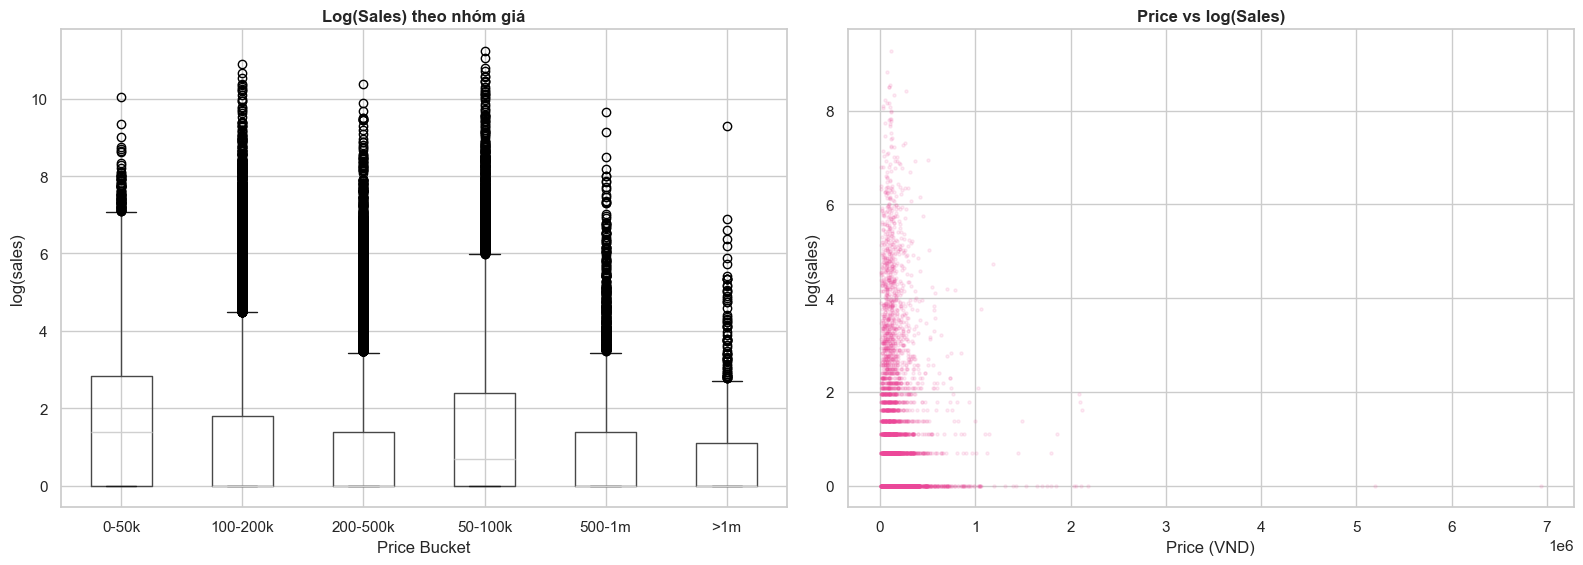

=> Sách giá thấp-trung bình (50k-200k) có doanh số cao nhất


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box by price bucket
if 'price_bucket' in df.columns:
    df.boxplot(column='log_sales', by='price_bucket', ax=axes[0])
    axes[0].set_title('Log(Sales) theo nhóm giá', fontweight='bold')
    axes[0].set_xlabel('Price Bucket')
    axes[0].set_ylabel('log(sales)')
    plt.suptitle('')

# Scatter
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['price'], sample['log_sales'], alpha=0.1, s=5, c='#ec4899')
axes[1].set_xlabel('Price (VND)')
axes[1].set_ylabel('log(sales)')
axes[1].set_title('Price vs log(Sales)', fontweight='bold')

plt.tight_layout()
plt.show()

print("=> Sách giá thấp-trung bình (50k-200k) có doanh số cao nhất")


---
## 7. Top 10 Category & Publisher theo doanh số


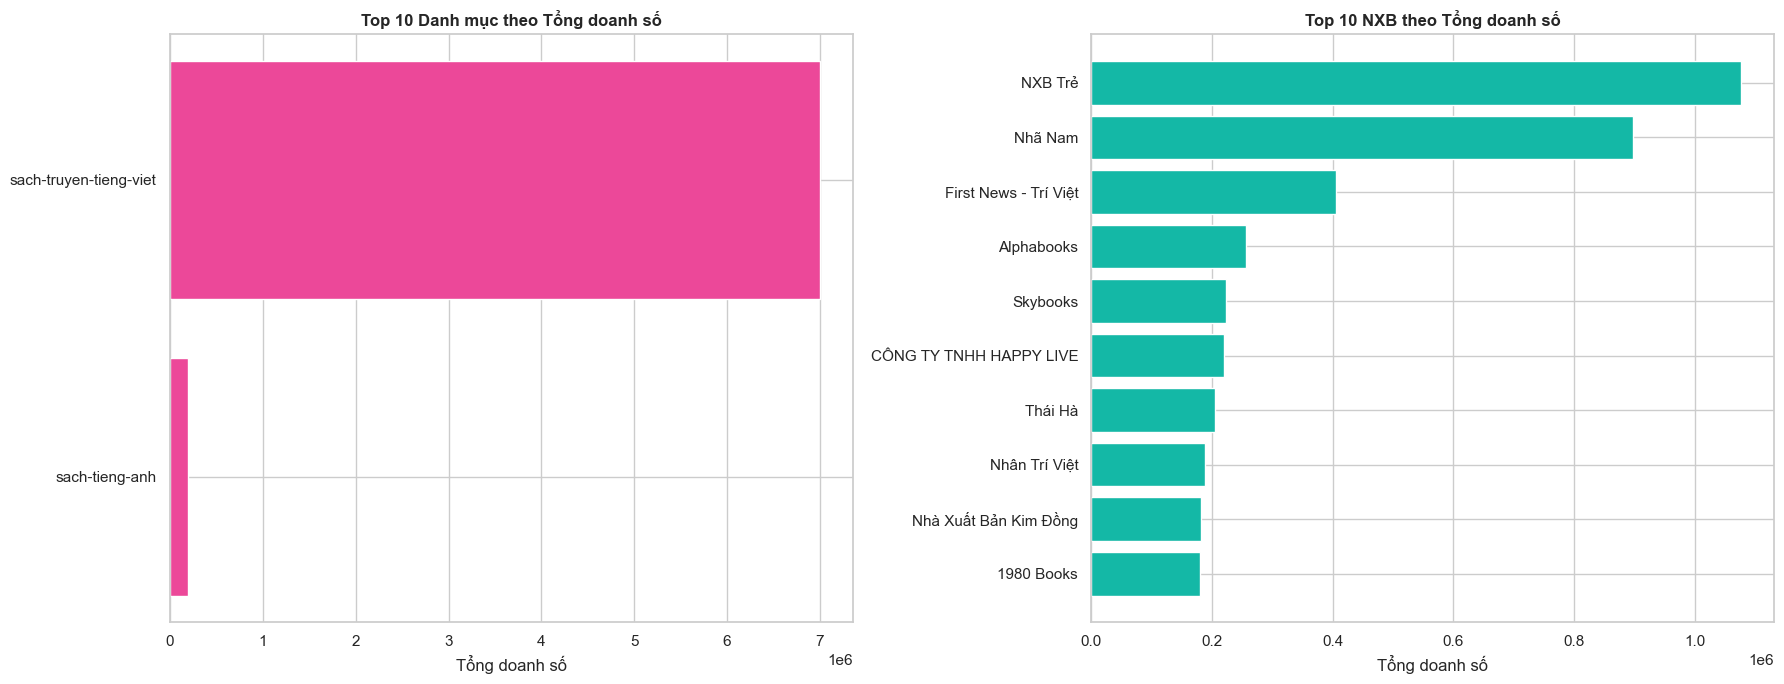

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Category
cat_sales = df.groupby('cat_level_2')['all_time_quantity_sold'].sum().nlargest(10).sort_values()
axes[0].barh(cat_sales.index, cat_sales.values, color='#ec4899', edgecolor='white')
axes[0].set_xlabel('Tổng doanh số')
axes[0].set_title('Top 10 Danh mục theo Tổng doanh số', fontweight='bold')

# Publisher
pub_sales = df.groupby('publisher_vn')['all_time_quantity_sold'].sum().nlargest(10).sort_values()
axes[1].barh(pub_sales.index, pub_sales.values, color='#14b8a6', edgecolor='white')
axes[1].set_xlabel('Tổng doanh số')
axes[1].set_title('Top 10 NXB theo Tổng doanh số', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 8. Số trang vs Doanh số


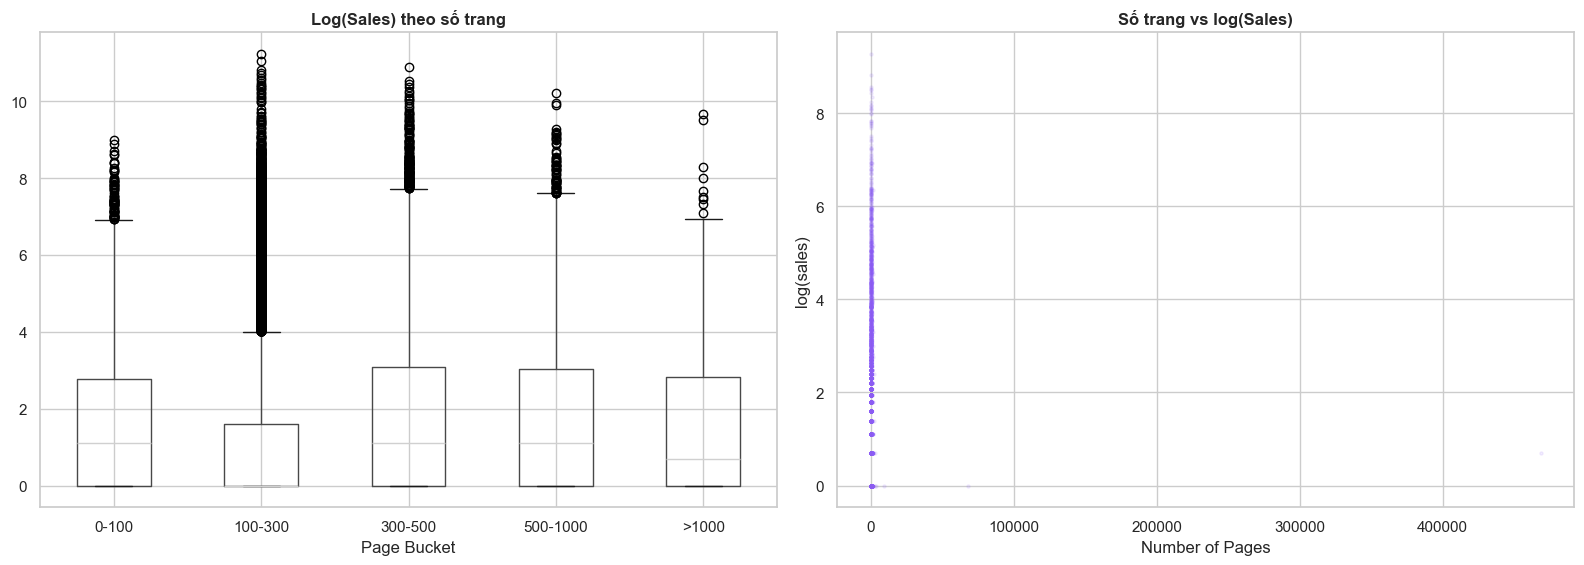

=> Sách 100-300 trang bán tốt nhất


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box
if 'page_bucket' in df.columns:
    df.boxplot(column='log_sales', by='page_bucket', ax=axes[0])
    axes[0].set_title('Log(Sales) theo số trang', fontweight='bold')
    axes[0].set_xlabel('Page Bucket')
    plt.suptitle('')

# Scatter
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['number_of_page'], sample['log_sales'], alpha=0.1, s=5, c='#8b5cf6')
axes[1].set_xlabel('Number of Pages')
axes[1].set_ylabel('log(sales)')
axes[1].set_title('Số trang vs log(Sales)', fontweight='bold')

plt.tight_layout()
plt.show()

print("=> Sách 100-300 trang bán tốt nhất")


---
## 9. Pairplot các features chính


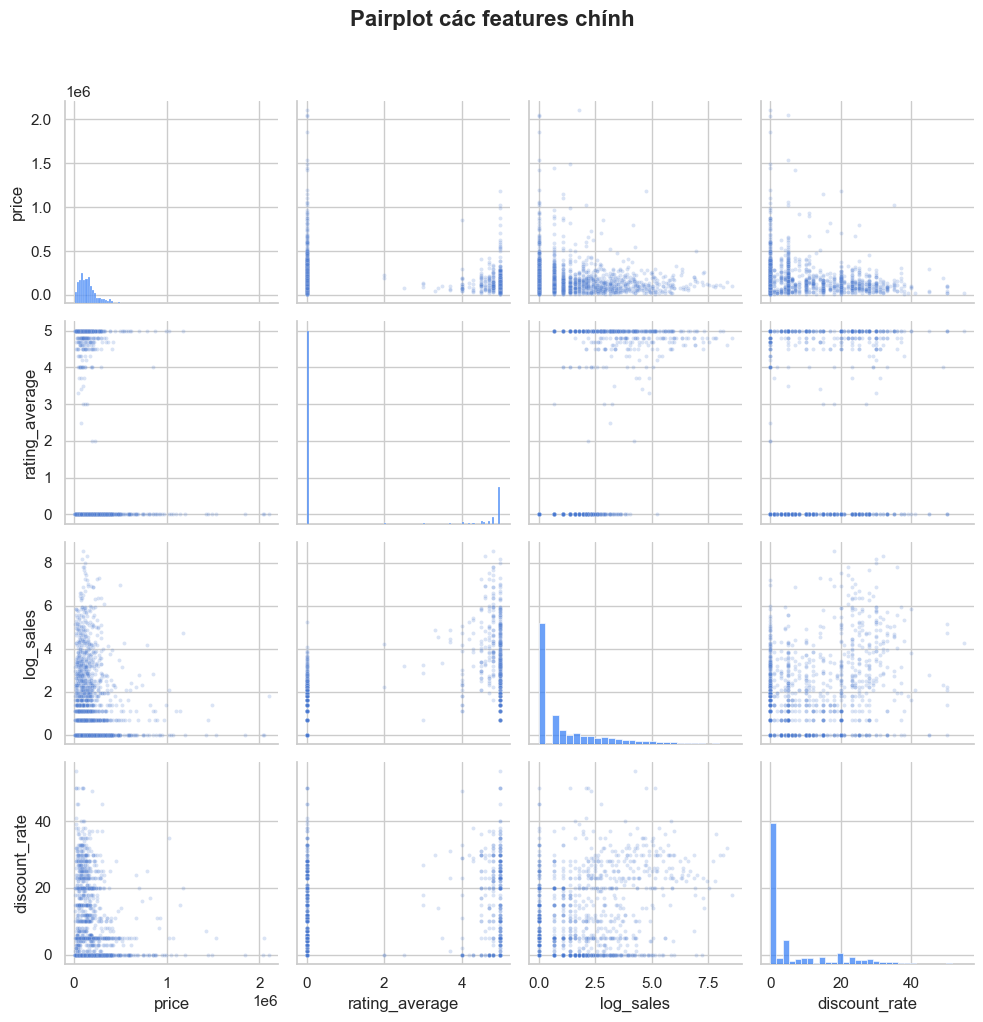

In [12]:
pair_cols = ['price', 'rating_average', 'log_sales', 'discount_rate']
sample_pair = df[pair_cols].dropna().sample(min(2000, len(df)), random_state=42)

g = sns.pairplot(sample_pair, diag_kind='hist', plot_kws={'alpha': 0.2, 's': 8},
                 diag_kws={'color': '#3b82f6', 'edgecolor': 'white'})
g.fig.suptitle('Pairplot các features chính', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 10. Kết luận EDA

### Key Insights:
1. **review_count** có tương quan **mạnh nhất** với doanh số → hiệu ứng đám đông
2. **rating** ở mức **4.5-5.0** cho doanh số cao nhất, nhưng sách 0 rating cũng rất nhiều
3. **discount** mức **20-30%** tối ưu nhất cho doanh số
4. **price** nhóm **50k-200k** bán chạy nhất
5. **Số trang** 100-300 là sweet spot
6. Phân phối doanh số **lệch phải cực mạnh** → bắt buộc log transform cho model

